# 🛣️ Notebook 07 — Análise da Malha Viária e Infraestrutura Logística
**Projeto:** Sinop Agro-GIS · **Autor:** Jakson Pascoal | github.com/Jk-Pascoal  
**Fontes de Dados:**
- **OpenStreetMap (OSM)** via Geofabrik (malha de rodovias recortada para Sinop-MT)
- **IBGE Malha Municipal 2022** (limite municipal recortado de Sinop-MT)

---

## Objetivos deste notebook:
1. Carregar a malha de rodovias recortada de Sinop-MT (`sinop_rodovias.shp`).
2. Reprojetar as camadas para coordenadas projetadas métricas (**SIRGAS 2000 / UTM Zone 21S - EPSG:31981**) para cálculos de distância de alta precisão.
3. Calcular a extensão total da malha viária e a **densidade viária** (km de rodovias por km² de área).
4. Agrupar as rodovias por categoria espacial (OSM `fclass`) e calcular a quilometragem de cada tipo.
5. Isolar e analisar especificamente a rodovia federal **BR-163** (o principal eixo de escoamento agrícola de Mato Grosso).
6. Exportar um mapa cartográfico profissional temático da malha logística.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# Configuração de Caminhos
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
MAPS_DIR = ROOT / 'maps' / 'exportados'
MAPS_DIR.mkdir(parents=True, exist_ok=True)

# Configuração de Estilo (Dark Mode Harmonioso)
BG = '#0a0a0f'
GRID = '#1a1a26'
TEXT_COLOR = '#e0e0e0'
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = BG
plt.rcParams['axes.facecolor'] = BG
plt.rcParams['grid.color'] = GRID
plt.rcParams['text.color'] = TEXT_COLOR
plt.rcParams['axes.labelcolor'] = TEXT_COLOR
plt.rcParams['xtick.color'] = TEXT_COLOR
plt.rcParams['ytick.color'] = TEXT_COLOR

SIGN = 'Jakson Pascoal  ·  github.com/Jk-Pascoal  ·  Sinop-MT'
FONTE = 'Fontes: OpenStreetMap (OSM) via Geofabrik & IBGE Malha Municipal 2022'
print('✅ Setup concluído com sucesso!')

✅ Setup concluído com sucesso!


## 1. Carregamento dos Shapefiles
Carregamos o limite municipal de Sinop-MT (`sinop_recorte.shp`) e a malha viária recortada pelo nosso script de logística (`sinop_rodovias.shp`).

In [2]:
limite_path = DATA_DIR / 'limite_municipal' / 'sinop_recorte.shp'
rodovias_path = DATA_DIR / 'malha_viaria' / 'sinop_rodovias.shp'

gdf_limite = gpd.read_file(limite_path)
gdf_rodovias = gpd.read_file(rodovias_path)

print(f'\u2713 Limite municipal de Sinop: CRS = {gdf_limite.crs}')
print(f'\u2713 Rodovias de Sinop: {len(gdf_rodovias):,} segmentos carregados. CRS = {gdf_rodovias.crs}')

✓ Limite municipal de Sinop: CRS = EPSG:4674
✓ Rodovias de Sinop: 6,394 segmentos carregados. CRS = EPSG:4674


## 2. Reprojeção e Métricas Espaciais (SIRGAS 2000 UTM Zone 21S)
Reprojetamos os dados de graus decimais para metros (EPSG:31981) para calcular com precisão a extensão física da malha viária em quilômetros e a densidade de vias no município.

In [3]:
# 1. Reprojetar para CRS métrico projetado para a região de Sinop (UTM 21S)
gdf_limite_utm = gdf_limite.to_crs(epsg=31981)
gdf_rodovias_utm = gdf_rodovias.to_crs(epsg=31981)

# 2. Calcular extensão de cada segmento de via em quilômetros
gdf_rodovias_utm['comprimento_km'] = gdf_rodovias_utm.geometry.length / 1000.0
total_rodovias_km = gdf_rodovias_utm['comprimento_km'].sum()

# 3. Calcular área do município em km²
area_sinop_km2 = gdf_limite_utm.geometry.area.sum() / 1_000_000.0

# 4. Calcular densidade viária (km de rodovias por km² de área)
densidade_viaria = total_rodovias_km / area_sinop_km2

print('='*60)
print('📐 MÉTRICAS LOGÍSTICAS DE SINOP-MT')
print('='*60)
print(f'  Área Municipal:        {area_sinop_km2:,.2f} km² ({area_sinop_km2*100:,.1f} ha)')
print(f'  Extensão da Malha:     {total_rodovias_km:,.2f} km de vias')
print(f'  Densidade Viária:      {densidade_viaria:.3f} km de vias por km²')
print('='*60)

📐 MÉTRICAS LOGÍSTICAS DE SINOP-MT
  Área Municipal:        3,990.34 km² (399,033.9 ha)
  Extensão da Malha:     3,640.42 km de vias
  Densidade Viária:      0.912 km de vias por km²


## 3. Classificação e Extensão por Tipo de Via
O OpenStreetMap classifica as vias de acordo com sua função e hierarquia (coluna `fclass`). Agrupamos os dados para identificar quais tipos de rodovias dominam a infraestrutura local, isolando e calculando a extensão da rodovia federal BR-163.

In [4]:
# 1. Extensão por tipo de via (fclass)
tabela_classes = (gdf_rodovias_utm
    .groupby('fclass')['comprimento_km']
    .agg(segmentos='count', total_km='sum')
    .sort_values('total_km', ascending=False)
)
tabela_classes['percentual (%)'] = (tabela_classes['total_km'] / total_rodovias_km * 100).round(2)

print('📊 Tabela de Tipos de Vias em Sinop:')
print(tabela_classes)

# 2. Isolar especificamente o eixo de escoamento principal - BR-163
# Filtramos segmentos que contenham '163' no nome ou na referência (ref)
mask_br163 = (
    gdf_rodovias_utm['name'].str.contains('163', na=False) |
    gdf_rodovias_utm['ref'].str.contains('163', na=False)
)
gdf_br163 = gdf_rodovias_utm[mask_br163]
extensao_br163_km = gdf_br163['comprimento_km'].sum()

print('\n' + '='*60)
print(f'🛣️  Extensão da Rodovia BR-163 dentro de Sinop: {extensao_br163_km:.2f} km')
print('='*60)

📊 Tabela de Tipos de Vias em Sinop:
                segmentos     total_km  percentual (%)
fclass                                                
residential          3736  1211.811429           33.29
unclassified          470  1109.903134           30.49
track                 290   515.332015           14.16
tertiary              529   273.754080            7.52
secondary             157   174.163061            4.78
service               705   167.988312            4.61
trunk                  82    81.308980            2.23
cycleway              107    59.698107            1.64
living_street         101    18.179244            0.50
footway                77    11.751975            0.32
path                   19     7.330770            0.20
track_grade3            1     3.519431            0.10
trunk_link             60     3.181651            0.09
tertiary_link          39     1.519761            0.04
secondary_link         21     0.975106            0.03

🛣️  Extensão da Rodovia BR-1

## 4. Visualização Cartográfica da Malha Viária
Plotamos o mapa espacial exibindo o limite municipal de Sinop-MT, as vias secundárias/locais de fundo e destacando a rodovia federal BR-163 (eixo vermelho), responsável pelo principal fluxo logístico da região norte de Mato Grosso.

✓ Mapa da malha viária exportado em alta resolução para: 15_malha_viaria_sinop.png


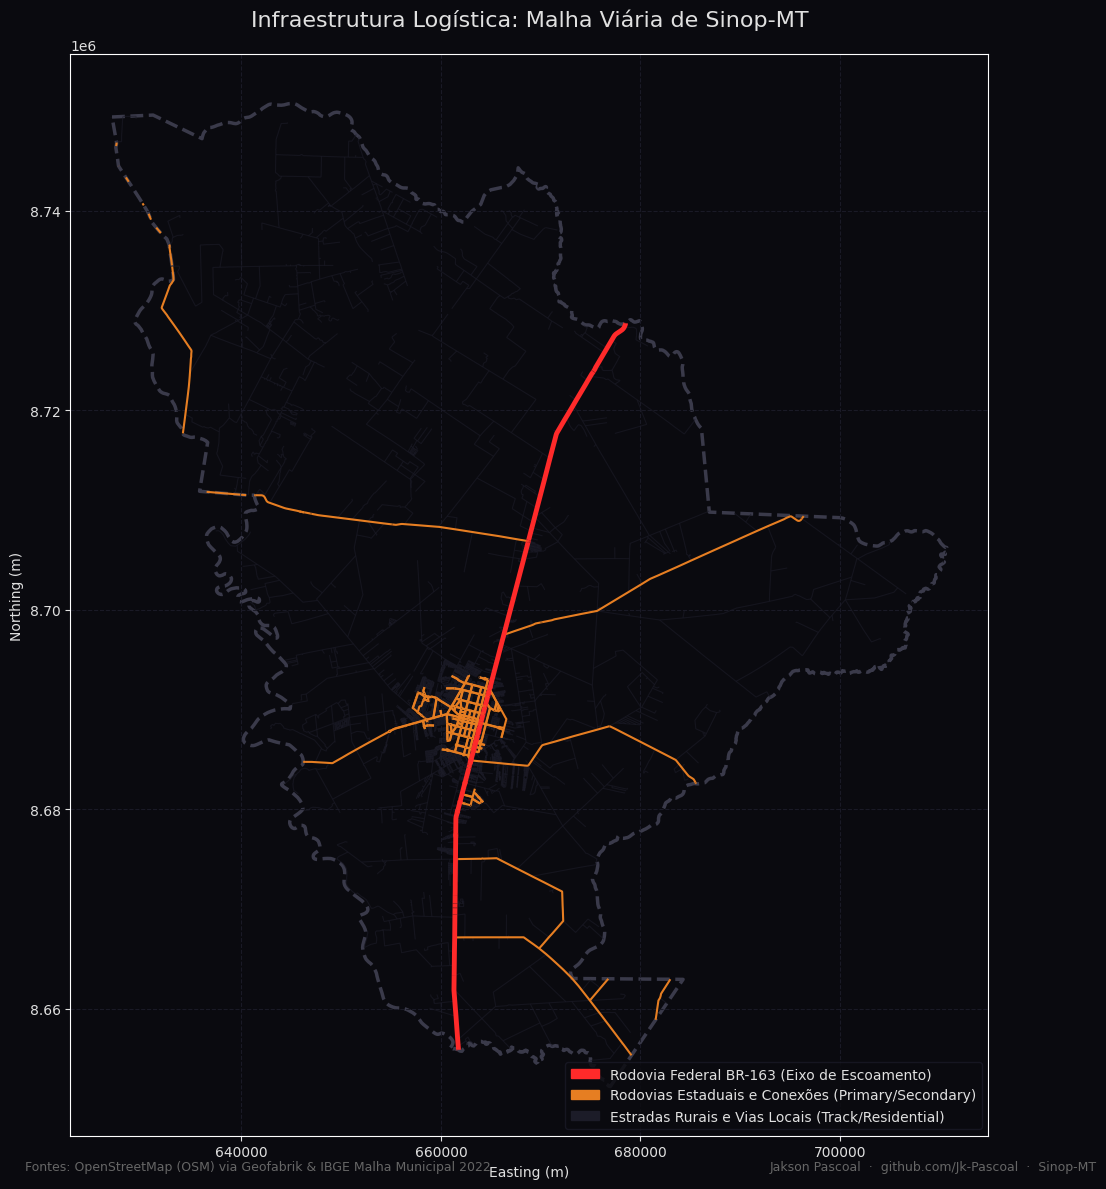

In [5]:
fig, ax = plt.subplots(figsize=(12, 12))

# 1. Plotar limite municipal (fundo e borda)
gdf_limite_utm.plot(ax=ax, color='none', edgecolor='#3a3a4a', linewidth=2.5, linestyle='--', zorder=1)

# 2. Plotar malha viária rural e local (secundária/fundo)
vias_secundarias = gdf_rodovias_utm[~mask_br163]
vias_secundarias.plot(
    ax=ax,
    color='#1c1c28',
    linewidth=0.8,
    alpha=0.6,
    zorder=2
)

# 3. Destacar rodovias de conexão secundária/estaduais (primary/secondary/tertiary)
classes_principais = ['primary', 'secondary', 'tertiary']
subset_rodovias = vias_secundarias[vias_secundarias['fclass'].isin(classes_principais)]
subset_rodovias.plot(
    ax=ax,
    color='#e67e22',
    linewidth=1.5,
    zorder=3
)

# 4. Destacar com linha espessa a Rodovia Federal BR-163
gdf_br163.plot(
    ax=ax,
    color='#ff2a2a',
    linewidth=3.5,
    zorder=4
)

# Configurações do gráfico
ax.set_title('Infraestrutura Logística: Malha Viária de Sinop-MT', color=TEXT_COLOR, fontsize=16, pad=20)
ax.set_xlabel('Easting (m)', color=TEXT_COLOR)
ax.set_ylabel('Northing (m)', color=TEXT_COLOR)
ax.grid(True, which='both', color=GRID, linestyle='--')

# Legenda personalizada explicativa
patches = [
    mpatches.Patch(color='#ff2a2a', label='Rodovia Federal BR-163 (Eixo de Escoamento)'),
    mpatches.Patch(color='#e67e22', label='Rodovias Estaduais e Conexões (Primary/Secondary)'),
    mpatches.Patch(color='#1c1c28', label='Estradas Rurais e Vias Locais (Track/Residential)')
]
ax.legend(handles=patches, facecolor=BG, edgecolor=GRID, loc='lower right', fontsize=10)

# Metadados e Assinatura
fig.text(0.08, 0.02, FONTE, color='#666666', fontsize=9)
fig.text(0.70, 0.02, SIGN, color='#666666', fontsize=9)

# Ajustar e salvar
plt.tight_layout()
output_map = MAPS_DIR / '15_malha_viaria_sinop.png'
plt.savefig(output_map, dpi=300, facecolor=BG)
print(f'\u2713 Mapa da malha viária exportado em alta resolução para: {output_map.name}')
plt.show()